In [1]:
import time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

RNG = np.random.default_rng(2026)
pd.set_option("display.width", 140)
DATA_PATH = "vct_2026_series.csv"
PLAYOFF_TEAMS = ["100T", "G2", "VIT", "NS", "NRG", "T1", "PRX", "LOUD"]

In [2]:
RUN_SCRAPER = False   # set True on your own machine

def scrape_vlr_event(event_id, event_order, event_name, delay=1.5):
    """Scrape completed series from https://www.vlr.gg/event/matches/<id>/.
    Returns rows in the same schema as the seed CSV."""
    import requests
    from bs4 import BeautifulSoup
    url = f"https://www.vlr.gg/event/matches/{event_id}/?series_id=all"
    html = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (student research)"}, timeout=20).text
    soup = BeautifulSoup(html, "html.parser")
    rows = []
    for item in soup.select("a.match-item"):
        names = [n.get_text(strip=True) for n in item.select(".match-item-vs-team-name .text-of")]
        scores = [s.get_text(strip=True) for s in item.select(".match-item-vs-team-score")]
        if len(names) != 2 or len(scores) != 2 or not all(s.isdigit() for s in scores):
            continue  # upcoming / TBD
        a, b = int(scores[0]), int(scores[1])
        w, l = (0, 1) if a > b else (1, 0)
        rows.append({
            "event_order": event_order, "event": event_name,
            "stage": item.select_one(".match-item-event-series").get_text(" ", strip=True) if item.select_one(".match-item-event-series") else "",
            "winner": names[w], "loser": names[l],
            "winner_maps": max(a, b), "loser_maps": min(a, b),
            "best_of": 5 if max(a, b) == 3 else 3, "score_status": "known",
        })
    time.sleep(delay)
    return pd.DataFrame(rows)

if RUN_SCRAPER:
    # (vlr_event_id, chronological order, label) — fill in the IDs you want
    EVENTS = [(2766, 7, "Champions Shanghai")]
    scraped = pd.concat([scrape_vlr_event(*e) for e in EVENTS], ignore_index=True)
    scraped.to_csv("vct_2026_series_scraped.csv", index=False)
    DATA_PATH = "vct_2026_series_scraped.csv"
    # NOTE: VLR uses full team names; map them to the short codes used below.
    print(scraped.shape)

### 1b. Load the dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"{len(df)} series, {df['event'].nunique()} events, "
      f"{pd.unique(df[['winner','loser']].values.ravel()).size} teams")
print(df["score_status"].value_counts().to_string())
df.tail(8)

40 series, 8 events, 19 teams
score_status
known          29
winner_only    11


,event_order,event,stage,winner,loser,winner_maps,loser_maps,best_of,score_status
32,7,Champions Shanghai,Group C Winners,PRX,G2,2.0,1.0,3,known
33,7,Champions Shanghai,Group C Elimination,TL,TYLOO,NaN,NaN,3,winner_only
34,7,Champions Shanghai,Group C Decider,G2,TL,2.0,0.0,3,known
35,7,Champions Shanghai,Group D Opening,NRG,NS,2.0,0.0,3,known
36,7,Champions Shanghai,Group D Opening,KC,XLG,NaN,NaN,3,winner_only
37,7,Champions Shanghai,Group D Winners,NRG,KC,2.0,1.0,3,known
38,7,Champions Shanghai,Group D Elimination,NS,XLG,2.0,0.0,3,known
39,7,Champions Shanghai,Group D Decider,NS,KC,2.0,1.0,3,known


In [4]:
# Quick EDA: series record of the 8 playoff teams in the dataset
rec = pd.DataFrame({
    "series_W": df["winner"].value_counts(),
    "series_L": df["loser"].value_counts(),
}).fillna(0).astype(int)
known = df[df.score_status == "known"]
rec["maps_W"] = (known.groupby("winner")["winner_maps"].sum()
                 .add(known.groupby("loser")["loser_maps"].sum(), fill_value=0))
rec["maps_L"] = (known.groupby("winner")["loser_maps"].sum()
                 .add(known.groupby("loser")["winner_maps"].sum(), fill_value=0))
rec = rec.fillna(0).astype(int)
rec.loc[PLAYOFF_TEAMS].sort_values("series_W", ascending=False)

,series_W,series_L,maps_W,maps_L
100T,9,2,15,8
G2,4,5,11,9
VIT,4,2,7,3
NS,4,3,11,7
LOUD,4,2,6,5
NRG,2,3,5,4
T1,2,2,5,6
PRX,2,2,6,8


In [5]:
def to_observations(frame, decay, ref_order=None):
    """Return list of (team_i, team_j, y, weight) where y=1 means team_i won the map."""
    ref = frame["event_order"].max() if ref_order is None else ref_order
    obs = []
    for r in frame.itertuples():
        w = decay ** (ref - r.event_order)
        if r.score_status == "known":
            obs += [(r.winner, r.loser, 1, w)] * int(r.winner_maps)
            obs += [(r.winner, r.loser, 0, w)] * int(r.loser_maps)
        else:
            obs.append((r.winner, r.loser, 1, w))
    return obs

obs_demo = to_observations(df, decay=0.8)
print(len(obs_demo), "map-level observations;", "example:", obs_demo[:3])

93 map-level observations; example: [('G2', '100T', 1, np.float64(0.2621440000000001)), ('G2', '100T', 1, np.float64(0.2621440000000001)), ('G2', '100T', 0, np.float64(0.2621440000000001))]


In [6]:
def fit_bt(obs, teams, C=1.0):
    idx = {t: k for k, t in enumerate(teams)}
    X, y, w = [], [], []
    for i, j, yy, ww in obs:
        row = np.zeros(len(teams)); row[idx[i]] = 1; row[idx[j]] = -1
        # add both orientations so the model is symmetric
        X += [row, -row]; y += [yy, 1 - yy]; w += [ww, ww]
    model = LogisticRegression(C=C, fit_intercept=False, max_iter=5000)
    model.fit(np.array(X), np.array(y), sample_weight=np.array(w))
    return dict(zip(teams, model.coef_[0]))

def p_map(r, a, b):
    return 1 / (1 + np.exp(-(r.get(a, 0.0) - r.get(b, 0.0))))

def p_series(p, best_of=3):
    """Probability of winning a BoN given independent map win prob p."""
    q = 1 - p
    if best_of == 3:
        return p**2 * (1 + 2*q)
    if best_of == 5:
        return p**3 * (1 + 3*q + 6*q**2)
    raise ValueError(best_of)

all_teams = sorted(pd.unique(df[["winner", "loser"]].values.ravel()))

In [7]:
def backtest(frame, C, decay, test_events=(5, 6, 7)):
    preds, ys = [], []
    for k in test_events:
        train = frame[frame.event_order < k]
        test = frame[frame.event_order == k]
        r = fit_bt(to_observations(train, decay, ref_order=k - 1), all_teams, C)
        for t in test.itertuples():
            # random orientation so "y" isn't always 1
            if RNG.random() < 0.5:
                preds.append(p_series(p_map(r, t.winner, t.loser), t.best_of)); ys.append(1)
            else:
                preds.append(p_series(p_map(r, t.loser, t.winner), t.best_of)); ys.append(0)
    preds = np.clip(preds, 1e-4, 1 - 1e-4)
    return log_loss(ys, preds, labels=[0, 1]), np.mean((preds > 0.5) == np.array(ys)), len(ys)

grid = []
for C in [0.1, 0.3, 1.0, 3.0, 10.0]:
    for decay in [0.5, 0.7, 0.85, 1.0]:
        ll, acc, n = backtest(df, C, decay)
        grid.append({"C": C, "decay": decay, "log_loss": ll, "accuracy": acc, "n_series": n})
grid = pd.DataFrame(grid).sort_values("log_loss")
print("Coin-flip baseline log loss = 0.693")
grid.head(8).round(3)

Coin-flip baseline log loss = 0.693


,C,decay,log_loss,accuracy,n_series
0,0.1,0.50,0.688,0.406,32
1,0.1,0.70,0.703,0.375,32
4,0.3,0.50,0.712,0.406,32
2,0.1,0.85,0.719,0.500,32
3,0.1,1.00,0.739,0.406,32
5,0.3,0.70,0.746,0.438,32
6,0.3,0.85,0.778,0.438,32
8,1.0,0.50,0.806,0.438,32


In [8]:
best = grid.iloc[0]
BEST_C, BEST_DECAY = float(best.C), float(best.decay)
print(f"Chosen C={BEST_C}, decay={BEST_DECAY}  ->  backtest log loss {best.log_loss:.3f}, "
      f"accuracy {best.accuracy:.0%} on {int(best.n_series)} series")
print("Caveat: with ~30 test series, a few upsets swing these numbers a lot.")

Chosen C=0.1, decay=0.5  ->  backtest log loss 0.688, accuracy 41% on 32 series
Caveat: with ~30 test series, a few upsets swing these numbers a lot.


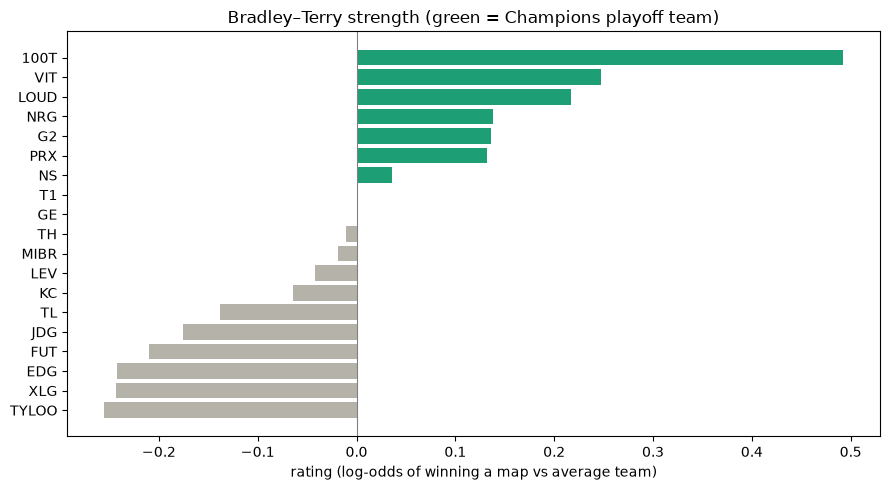

,rating,playoffs
100T,0.492,True
VIT,0.247,True
LOUD,0.217,True
NRG,0.138,True
G2,0.136,True
PRX,0.132,True
NS,0.036,True
T1,0.001,True
GE,0.001,False
TH,-0.011,False


In [9]:
ratings = fit_bt(to_observations(df, BEST_DECAY), all_teams, BEST_C)
rt = (pd.Series(ratings, name="rating").sort_values(ascending=False).to_frame())
rt["playoffs"] = rt.index.isin(PLAYOFF_TEAMS)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#1D9E75" if p else "#B4B2A9" for p in rt.playoffs]
ax.barh(rt.index[::-1], rt.rating[::-1], color=colors[::-1])
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Bradley–Terry strength (green = Champions playoff team)")
ax.set_xlabel("rating (log-odds of winning a map vs average team)")
plt.tight_layout(); plt.show()
rt.round(3)

In [ ]:
QF = [
    ("100T", "G2", 1.51, 2.42),
    ("VIT", "NS", 1.73, 2.00),
    ("NRG", "T1", 1.54, 2.33),
    ("PRX", "LOUD", 1.80, 1.92),
]
rows = []
for a, b, oa, ob in QF:
    ia, ib = 1 / oa, 1 / ob
    rows.append(
        {
            "match": f"{a} vs {b}",
            "model_P(team_a)": p_series(p_map(ratings, a, b), 3),
            "market_P(team_a)": ia / (ia + ib),
        }
    )
qf = pd.DataFrame(rows)
qf["model_pick"] = [
    a if p >= 0.5 else b for (a, b, *_), p in zip(QF, qf["model_P(team_a)"])
]
qf["gap_vs_market"] = qf["model_P(team_a)"] - qf["market_P(team_a)"]
qf.round(3)

,match,model_P(team_a),market_P(team_a),model_pick,gap_vs_market
0,100T vs G2,0.631,0.616,100T,0.015
1,VIT vs NS,0.579,0.536,VIT,0.042
2,NRG vs T1,0.551,0.602,NRG,-0.051
3,PRX vs LOUD,0.469,0.516,LOUD,-0.048


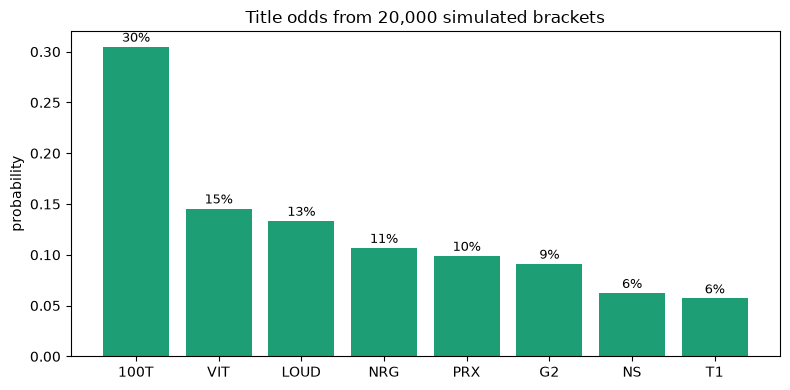

,P(champion),P(grand final),P(top 3)
100T,30.5%,46.1%,57.6%
VIT,14.6%,28.9%,41.9%
LOUD,13.3%,28.6%,42.5%
NRG,10.7%,24.2%,38.4%
PRX,9.9%,22.4%,35.5%
G2,9.1%,19.3%,30.2%
NS,6.2%,15.1%,26.0%
T1,5.7%,15.4%,27.8%


In [ ]:
def play(a, b, r, best_of=3, mode="sample"):
    p = p_series(p_map(r, a, b), best_of)
    if mode == "favourite":
        return (a, b, p) if p >= 0.5 else (b, a, 1 - p)
    return (a, b, p) if RNG.random() < p else (b, a, 1 - p)


def run_bracket(r, mode="sample"):
    res = {}

    def m(key, a, b, bo=3):
        w, l, p = play(a, b, r, bo, mode)
        res[key] = (w, l, p)
        return w, l

    wA, lA = m("UB QF A", "100T", "G2")
    wB, lB = m("UB QF B", "VIT", "NS")
    wC, lC = m("UB QF C", "NRG", "T1")
    wD, lD = m("UB QF D", "PRX", "LOUD")
    s1w, s1l = m("UB SF 1", wA, wB)
    s2w, s2l = m("UB SF 2", wC, wD)
    ufw, ufl = m("UB Final", s1w, s2w)
    l1w, _ = m("LB R1 top", lA, lB)
    l2w, _ = m("LB R1 bottom", lC, lD)
    r2a, _ = m("LB R2 top", s2l, l1w)
    r2b, _ = m("LB R2 bottom", s1l, l2w)
    lsw, _ = m("LB Semifinal", r2a, r2b)
    lfw, lfl = m("LB Final (Bo5)", ufl, lsw, 5)
    gfw, gfl = m("Grand Final (Bo5)", ufw, lfw, 5)
    res["_champion"], res["_runner_up"], res["_third"] = gfw, gfl, lfl
    return res


N = 20_000
sims = [run_bracket(ratings) for _ in range(N)]
odds = (
    pd.DataFrame(
        {
            "P(champion)": pd.Series([s["_champion"] for s in sims]).value_counts() / N,
            "P(grand final)": pd.Series(
                [t for s in sims for t in (s["_champion"], s["_runner_up"])]
            ).value_counts()
            / N,
            "P(top 3)": pd.Series(
                [
                    t
                    for s in sims
                    for t in (s["_champion"], s["_runner_up"], s["_third"])
                ]
            ).value_counts()
            / N,
        }
    )
    .reindex(PLAYOFF_TEAMS)
    .fillna(0)
    .sort_values("P(champion)", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(odds.index, odds["P(champion)"], color="#1D9E75")
ax.set_ylabel("probability")
ax.set_title(f"Title odds from {N:,} simulated brackets")
for x, v in enumerate(odds["P(champion)"]):
    ax.text(x, v + 0.005, f"{v:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
(odds * 100).round(1).astype(str) + "%"

In [ ]:
picks = run_bracket(ratings, mode="favourite")
sheet = pd.DataFrame(
    [
        {"#": i + 1, "match": k, "pick": w, "vs": l, "confidence": f"{p:.0%}"}
        for i, (k, (w, l, p)) in enumerate(
            (k, v) for k, v in picks.items() if not k.startswith("_")
        )
    ]
).set_index("#")
print(
    f"Champion: {picks['_champion']}   Runner-up: {picks['_runner_up']}   Third: {picks['_third']}"
)
sheet

Champion: 100T   Runner-up: VIT   Third: LOUD


,match,pick,vs,confidence
#,,,,
1,UB QF A,100T,G2,63%
2,UB QF B,VIT,NS,58%
3,UB QF C,NRG,T1,55%
4,UB QF D,LOUD,PRX,53%
5,UB SF 1,100T,VIT,59%
6,UB SF 2,LOUD,NRG,53%
7,UB Final,100T,LOUD,60%
8,LB R1 top,G2,NS,54%
9,LB R1 bottom,PRX,T1,55%
